Propagazione FULL PERTURBATIONS MOLNIYA in corso per 30 giorni...

  MISSION ANALYSIS: HEO MOLNIYA DOPO 30 GIORNI
  Modello: Gravità 10x10, Atm Drag, SRP, Luni-Solar Third Body
1. SEMIASSE MAGGIORE (a)
   Iniziale: 26562.000 km
   Finale:   26690.544 km
   Delta:    128544.46 metri 
--------------------------------------------------------------------
2. ECCENTRICITÀ (e)
   Iniziale: 0.740000
   Finale:   0.740805
   Delta:    0.000805 (Third Body perturbations dominano)
--------------------------------------------------------------------
3. INCLINAZIONE (i)
   Iniziale: 63.43490 deg
   Finale:   63.45367 deg
   Delta:    0.01877 deg (Oscillazioni per Third Body/J2)
--------------------------------------------------------------------
4. RAAN (Ω)
   Iniziale: 0.000 deg
   Finale:   355.413 deg (Standard Modulo 360)
             -4.587 deg (Valore Reale Propagato)
   Delta:    -4.587 deg (Deriva reale normalizzata)
--------------------------------------------------------------------
5. AR

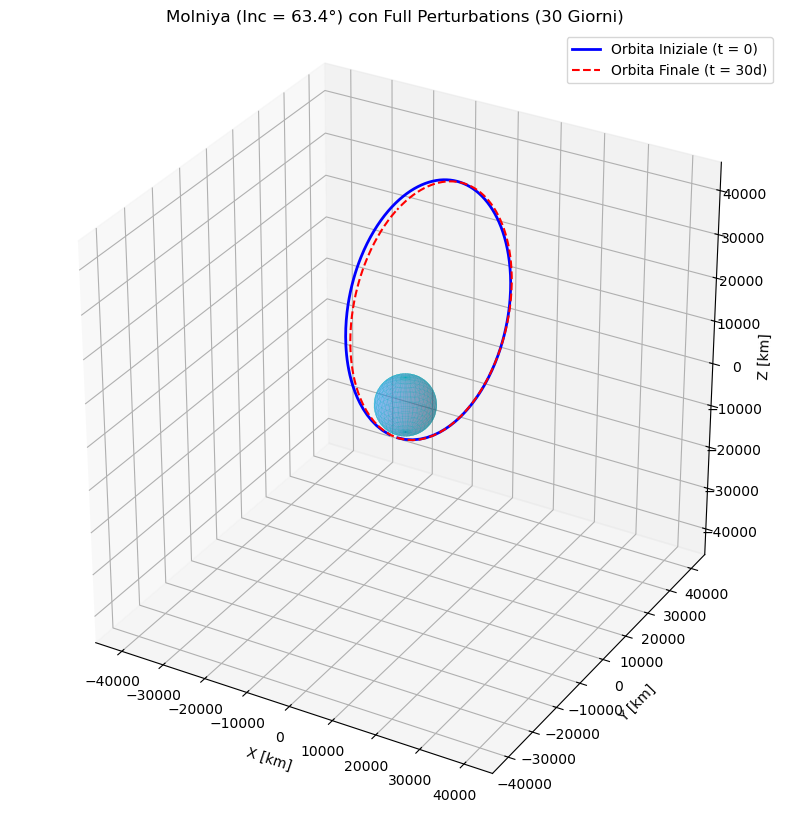

In [4]:
import math
import numpy as np
import matplotlib.pyplot as plt
import orekit
from orekit.pyhelpers import setup_orekit_curdir
from orekit import JArray_double

# ==========================================
# 1. INIZIALIZZAZIONE AMBIENTE OREKIT
# ==========================================
orekit.initVM()
setup_orekit_curdir('C:/Users/Simone/Downloads/orekit-data-main')

from org.orekit.orbits import KeplerianOrbit, PositionAngleType
from org.orekit.frames import FramesFactory
from org.orekit.time import TimeScalesFactory, AbsoluteDate
from org.orekit.utils import Constants, IERSConventions
from org.orekit.propagation.numerical import NumericalPropagator
from org.hipparchus.ode.nonstiff import DormandPrince853Integrator
from org.orekit.propagation import SpacecraftState

from org.orekit.forces.gravity.potential import GravityFieldFactory
from org.orekit.forces.gravity import HolmesFeatherstoneAttractionModel, ThirdBodyAttraction
from org.orekit.forces.drag import DragForce, IsotropicDrag
from org.orekit.models.earth.atmosphere import HarrisPriester
from org.orekit.bodies import CelestialBodyFactory, OneAxisEllipsoid
from org.orekit.forces.radiation import SolarRadiationPressure, IsotropicRadiationSingleCoefficient

# ==========================================
# 2. DEFINIZIONE DEL TEMPO E DEI FRAME
# ==========================================
utc = TimeScalesFactory.getUTC()
initial_date = AbsoluteDate(2026, 8, 4, 12, 0, 0.0, utc)

inertial_frame = FramesFactory.getEME2000()
earth_frame = FramesFactory.getITRF(IERSConventions.IERS_2010, True)
earth_shape = OneAxisEllipsoid(Constants.WGS84_EARTH_EQUATORIAL_RADIUS, 
                               Constants.WGS84_EARTH_FLATTENING, 
                               earth_frame)
mu = Constants.WGS84_EARTH_MU

# ==========================================
# 3. CREAZIONE DELL'ORBITA MOLNIYA
# ==========================================
a = 26562000.0  # Semiasse per periodo di 12h
e = 0.74        # Eccentricita' altissima
i = math.radians(63.4349)  # Inclinazione critica per "congelare" l'argomento del perigeo
omega = math.radians(270.0) # Perigeo a Sud, Apogeo (picco) a Nord
raan = math.radians(0.0)
lM = math.radians(0.0)

initial_orbit = KeplerianOrbit(a, e, i, omega, raan, lM, PositionAngleType.MEAN, inertial_frame, initial_date, mu)
initial_state = SpacecraftState(initial_orbit, 1000.0)

# ==========================================
# 4. CONFIGURAZIONE DEL PROPAGATORE
# ==========================================
min_step = 0.001
max_step = 300.0
position_tolerance = 10.0 
tolerances = NumericalPropagator.tolerances(position_tolerance, initial_orbit, initial_orbit.getType())
abs_tolerance = JArray_double.cast_(tolerances[0])
rel_tolerance = JArray_double.cast_(tolerances[1])

integrator = DormandPrince853Integrator(min_step, max_step, abs_tolerance, rel_tolerance)
propagator = NumericalPropagator(integrator)
propagator.setInitialState(initial_state)
ephemeris_generator = propagator.getEphemerisGenerator()

# ==========================================
# 5. AGGIUNTA DI TUTTE LE PERTURBAZIONI
# ==========================================
gravity_provider = GravityFieldFactory.getNormalizedProvider(10, 10)
propagator.addForceModel(HolmesFeatherstoneAttractionModel(earth_frame, gravity_provider))

sun = CelestialBodyFactory.getSun()
moon = CelestialBodyFactory.getMoon()
propagator.addForceModel(ThirdBodyAttraction(sun))
propagator.addForceModel(ThirdBodyAttraction(moon))

atmosphere = HarrisPriester(sun, earth_shape)
propagator.addForceModel(DragForce(atmosphere, IsotropicDrag(15.0, 2.2)))

propagator.addForceModel(SolarRadiationPressure(sun, earth_shape, IsotropicRadiationSingleCoefficient(15.0, 1.8)))

# ==========================================
# 6. PROPAGAZIONE (30 GIORNI)
# ==========================================
giorni = 30.0
duration = giorni * 24.0 * 3600.0  
final_date = initial_date.shiftedBy(duration)

print(f"Propagazione FULL PERTURBATIONS MOLNIYA in corso per {int(giorni)} giorni...")
final_state = propagator.propagate(final_date)
orbit_30d = KeplerianOrbit(final_state.getOrbit())

# ==========================================
# 7. MISSION ANALYSIS REPORT
# ==========================================
a_fin = orbit_30d.getA()
e_fin = orbit_30d.getE()
i_fin = math.degrees(orbit_30d.getI())

# Estrazione valori grezzi (reali propagati, che possono essere negativi o > 360)
raan_fin_raw = math.degrees(orbit_30d.getRightAscensionOfAscendingNode())
omega_fin_raw = math.degrees(orbit_30d.getPerigeeArgument())

# Valori standardizzati col modulo 360 per la notazione Kepleriana classica
raan_fin_mod = raan_fin_raw % 360.0
omega_fin_mod = omega_fin_raw % 360.0

# Calcolo del Delta fisico normalizzato (spostamento effettivo relativo allo zero, tra -180° e +180°)
delta_raan = (raan_fin_raw - math.degrees(raan) + 180.0) % 360.0 - 180.0
delta_omega = (omega_fin_raw - math.degrees(omega) + 180.0) % 360.0 - 180.0

print("\n====================================================================")
print(f"  MISSION ANALYSIS: HEO MOLNIYA DOPO {int(giorni)} GIORNI")
print("  Modello: Gravità 10x10, Atm Drag, SRP, Luni-Solar Third Body")
print("====================================================================")
print(f"1. SEMIASSE MAGGIORE (a)")
print(f"   Iniziale: {a/1000:.3f} km")
print(f"   Finale:   {a_fin/1000:.3f} km")
print(f"   Delta:    {((a_fin - a)):.2f} metri ")
print("--------------------------------------------------------------------")
print(f"2. ECCENTRICITÀ (e)")
print(f"   Iniziale: {e:.6f}")
print(f"   Finale:   {e_fin:.6f}")
print(f"   Delta:    {e_fin - e:.6f} (Third Body perturbations dominano)")
print("--------------------------------------------------------------------")
print(f"3. INCLINAZIONE (i)")
print(f"   Iniziale: {math.degrees(i):.5f} deg")
print(f"   Finale:   {i_fin:.5f} deg")
print(f"   Delta:    {i_fin - math.degrees(i):.5f} deg (Oscillazioni per Third Body/J2)")
print("--------------------------------------------------------------------")
print(f"4. RAAN (\u03A9)")
print(f"   Iniziale: {math.degrees(raan):.3f} deg")
print(f"   Finale:   {raan_fin_mod:.3f} deg (Standard Modulo 360)")
print(f"             {raan_fin_raw:.3f} deg (Valore Reale Propagato)")
print(f"   Delta:    {delta_raan:.3f} deg (Deriva reale normalizzata)")
print("--------------------------------------------------------------------")
print(f"5. ARGOMENTO DEL PERIGEO (\u03C9) -> FROZEN ORBIT")
print(f"   Iniziale: {math.degrees(omega):.3f} deg")
print(f"   Finale:   {omega_fin_mod:.3f} deg (Standard Modulo 360)")
print(f"             {omega_fin_raw:.3f} deg (Valore Reale Propagato)")
print(f"   Delta:    {delta_omega:.3f} deg")
print("   Risultato: Pur con Sole, Luna, Atmosfera e Gravità 10x10, \u03C9 resta BLOCCATO a ~270°")
print("====================================================================\n")

# ==========================================
# 8. VISUALIZZAZIONE 3D
# ==========================================
print("Generazione grafico 3D in corso...")
ephemeris = ephemeris_generator.getGeneratedEphemeris()
periodo_orbitale = 43200.0  

def estrai_orbita(start_time, end_time):
    times = np.linspace(start_time, end_time, 250)
    x, y, z = [], [], []
    for t in times:
        current_date = initial_date.shiftedBy(float(t))
        pos = ephemeris.propagate(current_date).getPVCoordinates().getPosition()
        x.append(pos.getX() / 1000.0)
        y.append(pos.getY() / 1000.0)
        z.append(pos.getZ() / 1000.0)
    return x, y, z

x0, y0, z0 = estrai_orbita(0, periodo_orbitale)                                  
x30, y30, z30 = estrai_orbita(duration - periodo_orbitale, duration)             

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

u, v = np.mgrid[0:2*np.pi:40j, 0:np.pi:20j]
R_E_km = Constants.WGS84_EARTH_EQUATORIAL_RADIUS / 1000.0
x_earth = R_E_km * np.cos(u) * np.sin(v)
y_earth = R_E_km * np.sin(u) * np.sin(v)
z_earth = R_E_km * np.cos(v)
ax.plot_surface(x_earth, y_earth, z_earth, color='dodgerblue', alpha=0.3, edgecolor='c', linewidth=0.2)

ax.plot(x0, y0, z0, color='blue', linewidth=2.0, label='Orbita Iniziale (t = 0)')
ax.plot(x30, y30, z30, color='red', linewidth=1.5, linestyle='dashed', label='Orbita Finale (t = 30d)')

lim = R_E_km + 40000 
ax.set_xlim([-lim, lim]); ax.set_ylim([-lim, lim]); ax.set_zlim([-lim, lim])
ax.set_box_aspect([1,1,1]) 

ax.set_xlabel('X [km]'); ax.set_ylabel('Y [km]'); ax.set_zlabel('Z [km]')
ax.set_title('Molniya (Inc = 63.4°) con Full Perturbations (30 Giorni)')
ax.legend(loc='upper right')

plt.show()